# Fairness Analysis

With the labels predicted in the test sample of the predictive analysis, the **Aequitas** toolkit is used to assess the fairness of the model's predictions across different demographic and health-related groups.

Fairness analysis helps identify whether a predictive model performs differently for certain groups of individuals, which could lead to biased outcomes.

In this section we:
- Prepare the dataset for fairness evaluation
- Compute fairness metrics using Aequitas
- Compare disparities across different demographic and health attributes
- Visualize disparities using tree maps

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import aequitas as aq
from aequitas.plotting import Plot
from aequitas.group import Group
from aequitas.bias import Bias
from aequitas.fairness import Fairness
import aequitas.plot as ap

In [2]:
df = pd.read_csv('data/diabetes_with_predicted_labels.csv')
df.nunique()

Unnamed: 0              14139
Diabetes_012                2
HighBP                      2
HighChol                    2
CholCheck                   2
BMI                        68
Smoker                      2
Stroke                      2
HeartDiseaseorAttack        2
PhysActivity                2
Fruits                      2
Veggies                     2
HvyAlcoholConsump           2
AnyHealthcare               2
NoDocbcCost                 2
GenHlth                     5
MentHlth                   30
PhysHlth                   30
DiffWalk                    2
Sex                         2
Age                        13
Education                   6
Income                      8
CholxCheck                  2
BMIxChol                   61
IncomexAge                 71
BPxAge                     14
BPxChol                     2
AgexBMI                   348
AgexGenHlth                40
label_value                 2
score                       2
BMI_categorical             6
dtype: int

## Data Preprocessing

Some variables contain many categories that make fairness analysis difficult to interpret.  
To simplify the analysis:

- **Age** is grouped into bins
- **Income** is grouped into broader ranges

This allows the fairness metrics to be evaluated across meaningful demographic groups.

In [3]:
# Data Preprocessing to have less categories
df['Age'] = pd.cut(df['Age'], bins=[0, 2, 4, 6, 8, 10, 13], 
                   labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-13'])

df['Income'] = pd.cut(df['Income'], bins=[1, 3, 5, 6, 8], 
                      labels=['1-2', '3-4', '5-6', '7-8'], include_lowest=True)

## Feature Selection

Only the features relevant for fairness analysis are kept in the dataset:

- Prediction score
- True label
- Age
- BMI category
- Blood Pressure × Cholesterol
- General Health
- Income

In [4]:
# Selection of the features used in the predictive analysis
df = df[['score', 'label_value', 'Age', 'BMI_categorical', 
         'BPxChol', 'GenHlth', 'Income']]

## Data Type Formatting

Aequitas requires categorical attributes to be stored as **string values**.  
Therefore, all categorical columns are converted to strings while prediction score and labels remain numerical.

In [5]:
# Convert categorical columns to string
non_string_cols = df.columns[(df.dtypes != object) & (df.dtypes != str)]
df[non_string_cols] = df[non_string_cols].astype(str)

df['score'] = df['score'].astype(float)
df['label_value'] = df['label_value'].astype(float)

## Group Metrics Calculation

Aequitas first computes **group-level performance metrics** using cross-tabulations.

These metrics include:
- Precision
- Recall
- False positive rate
- True positive rate

The metrics are calculated separately for each value of each attribute.

In [6]:
group = Group()
xtab, _ = group.get_crosstabs(df)

absolute_metrics = group.list_absolute_metrics(xtab)

xtab[['attribute_name', 'attribute_value'] + absolute_metrics].round(2)

,attribute_name,attribute_value,tpr,tnr,for,fdr,fpr,fnr,npv,precision,ppr,pprev,prev
0,Age,0-2,0.14,0.99,0.08,0.45,0.01,0.86,0.92,0.55,0.00,0.02,0.09
1,Age,10-13,0.73,0.57,0.43,0.28,0.43,0.27,0.57,0.72,0.32,0.61,0.61
2,Age,2-4,0.30,0.95,0.14,0.43,0.05,0.70,0.86,0.57,0.01,0.10,0.19
3,Age,4-6,0.56,0.87,0.21,0.31,0.13,0.44,0.79,0.69,0.06,0.27,0.34
4,Age,6-8,0.78,0.69,0.21,0.31,0.31,0.22,0.79,0.69,0.23,0.53,0.47
5,Age,8-10,0.81,0.62,0.32,0.24,0.38,0.19,0.68,0.76,0.37,0.63,0.60
6,BMI_categorical,Healthy,0.37,0.91,0.21,0.36,0.09,0.63,0.79,0.64,0.09,0.17,0.29
7,BMI_categorical,Obesity Class I,0.92,0.41,0.24,0.29,0.59,0.08,0.76,0.71,0.34,0.79,0.61
8,BMI_categorical,Obesity Class II,0.89,0.41,0.41,0.20,0.59,0.11,0.59,0.80,0.15,0.81,0.73
9,BMI_categorical,Overweight,0.64,0.74,0.30,0.32,0.26,0.36,0.70,0.68,0.29,0.43,0.47


## Bias and Disparity Analysis

Disparity metrics measure how different a group’s performance is compared to a **reference group**.

In this analysis, the reference group represents **healthy individuals with average demographic characteristics** within the dataset.

Reference group characteristics:

- **Age:** `6–8` (approximately 45–54 years old)
- **BMI:** `Healthy`
- **Blood Pressure × Cholesterol:** `0.0`
- **General Health:** `2.0` (out of 5 bins)
- **Income:** `3–4` (approximately \$20,000–\$25,000 yearly)

Disparity coefficients equal **1** for the reference group because all other groups are compared against it.

In [7]:
bias = Bias()

bias_df = bias.get_disparity_predefined_groups(
    xtab,
    original_df=df,
    ref_groups_dict={
        'Age': '6-8',
        'BMI_categorical': 'Healthy',
        'BPxChol': '0.0',
        'GenHlth': '2.0',
        'Income': '3-4'
    },
    alpha=0.05,
    check_significance=True,
    mask_significance=True
)

bias_df.style

get_disparity_predefined_group()


/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/2A/S4_TU_Delft/Q3/SEN163B-Responsible_Data_Analytics/Diabetes_Prediction/project_final/diabetes_venv/lib/python3.9/site-packages/aequitas/bias.py:449: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[True, True, True, True, False, True, False, True, True, True, True, False, False, True, True, False, True, True, True, True, False, True, True]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[:, significance_cols] = np.select(
/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/2A/S4_TU_Delft/Q3/SEN163B-Responsible_Data_Analytics/Diabetes_Prediction/project_final/diabetes_venv/lib/python3.9/site-packages/aequitas/bias.py:449: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[True, True, True, Fals

,model_id,score_threshold,k,attribute_name,attribute_value,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,label_value_significance,score_significance,fdr_disparity,fdr_ref_group_value,fdr_significance,fnr_disparity,fnr_ref_group_value,fnr_significance,for_disparity,for_ref_group_value,for_significance,fpr_disparity,fpr_ref_group_value,fpr_significance,npv_disparity,npv_ref_group_value,npv_significance,ppr_disparity,ppr_ref_group_value,ppr_significance,pprev_disparity,pprev_ref_group_value,pprev_significance,precision_disparity,precision_ref_group_value,precision_significance,tnr_disparity,tnr_ref_group_value,tnr_significance,tpr_disparity,tpr_ref_group_value,tpr_significance
0,0,binary 0/1,7144,Age,0-2,0.142857,0.988345,0.078261,0.454545,0.011655,0.857143,0.921739,0.545455,11,460,0.001540,0.023355,5,36,424,6,42,429,471,14139,0.089172,True,True,1.459517,6-8,False,3.937415,6-8,True,0.364224,6-8,True,0.037856,6-8,False,1.173996,6-8,True,0.006691,6-8,True,0.044180,6-8,True,0.792162,6-8,False,1.427991,6-8,False,0.182610,6-8,True
1,0,binary 0/1,7144,Age,10-13,0.725447,0.566849,0.430822,0.276448,0.433151,0.274553,0.569178,0.723552,2297,1460,0.321529,0.611392,635,629,831,1662,2291,1466,3757,14139,0.609795,True,True,0.887656,6-8,True,1.261199,6-8,True,2.005032,6-8,True,1.406896,6-8,True,0.724948,6-8,True,1.397202,6-8,True,1.156587,6-8,True,1.050813,6-8,True,0.819000,6-8,True,0.927317,6-8,True
2,0,binary 0/1,7144,Age,2-4,0.300546,0.947566,0.144307,0.432990,0.052434,0.699454,0.855693,0.567010,97,887,0.013578,0.098577,42,128,759,55,183,801,984,14139,0.185976,True,True,1.390303,6-8,True,3.213045,6-8,True,0.671599,6-8,True,0.170310,6-8,True,1.089875,6-8,True,0.059002,6-8,True,0.186481,6-8,True,0.823467,6-8,True,1.369072,6-8,True,0.384179,6-8,True
3,0,binary 0/1,7144,Age,4-6,0.555160,0.873162,0.208333,0.306667,0.126838,0.444840,0.791667,0.693333,450,1200,0.062990,0.272727,138,250,950,312,562,1088,1650,14139,0.340606,True,True,0.984687,6-8,False,2.043439,6-8,False,0.969577,6-8,False,0.411977,6-8,False,1.008326,6-8,False,0.273723,6-8,True,0.515926,6-8,True,1.006926,6-8,False,1.261571,6-8,False,0.709644,6-8,False
4,0,binary 0/1,7144,Age,6-8,0.782308,0.692123,0.214870,0.311436,0.307877,0.217692,0.785130,0.688564,1644,1466,0.230123,0.528617,512,315,1151,1132,1447,1663,3110,14139,0.465273,False,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False,1.000000,6-8,False
5,0,binary 0/1,7144,Age,8-10,0.806841,0.619501,0.315375,0.241966,0.380499,0.193159,0.684625,0.758034,2645,1522,0.370241,0.634749,640,480,1042,2005,2485,1682,4167,14139,0.596352,True,True,0.776938,6-8,True,0.887305,6-8,True,1.467743,6-8,True,1.235880,6-8,True,0.871990,6-8,True,1.608881,6-8,True,1.200773,6-8,True,1.100890,6-8,True,0.895073,6-8,True,1.031360,6-8,True
6,0,binary 0/1,7144,BMI_categorical,Healthy,0.374881,0.914602,0.214987,0.362460,0.085398,0.625119,0.785013,0.637540,618,3056,0.086506,0.168209,224,657,2399,394,1051,2623,3674,14139,0.286064,False,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False,1.000000,Healthy,False
7,0,binary 0/1,7144,BMI_categorical,Obesity Class I,0.915219,0.413565,0.243570,0.289743,0.586435,0.084781,0.756430,0.710257,2447,661,0.342525,0.787323,709,161,500,1738,1899,1209,3108,14139,0.611004,True,True,0.799379,Healthy,True,0.135625,Healthy,False,1.132954,Healthy,False,6.867050,Healthy,True,0.963589,Healthy,False,3.959547,Healthy,True,4.680623,Healthy,True,1.114059,Healthy,True,0.452180,Healthy,True,2.441357,Healthy,False
8,0,binary 0/1,7144,BMI_categorical,Obesity Class II,0.892137,0.412869,0.409962,0.198370,0.587131,0.107863,0.590038,0.801630,1104,261,0.154535,0.808791,219,107,154,885,992,373,

## Disparity Metrics Overview

The following table shows disparity metrics and their statistical significance.

These values indicate how far each group's prediction performance deviates from the reference group.

In [8]:
bias_df[['attribute_name', 'attribute_value'] +
        bias.list_disparities(bias_df) +
        bias.list_significance(bias_df)].style

,attribute_name,attribute_value,fdr_disparity,fnr_disparity,for_disparity,fpr_disparity,npv_disparity,ppr_disparity,pprev_disparity,precision_disparity,tnr_disparity,tpr_disparity,label_value_significance,score_significance,fdr_significance,fnr_significance,for_significance,fpr_significance,npv_significance,ppr_significance,pprev_significance,precision_significance,tnr_significance,tpr_significance
0,Age,0-2,1.459517,3.937415,0.364224,0.037856,1.173996,0.006691,0.044180,0.792162,1.427991,0.182610,True,True,False,True,True,False,True,True,True,False,False,True
1,Age,10-13,0.887656,1.261199,2.005032,1.406896,0.724948,1.397202,1.156587,1.050813,0.819000,0.927317,True,True,True,True,True,True,True,True,True,True,True,True
2,Age,2-4,1.390303,3.213045,0.671599,0.170310,1.089875,0.059002,0.186481,0.823467,1.369072,0.384179,True,True,True,True,True,True,True,True,True,True,True,True
3,Age,4-6,0.984687,2.043439,0.969577,0.411977,1.008326,0.273723,0.515926,1.006926,1.261571,0.709644,True,True,False,False,False,False,False,True,True,False,False,False
4,Age,6-8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,False,False,False,False,False,False,False,False,False,False,False,False
5,Age,8-10,0.776938,0.887305,1.467743,1.235880,0.871990,1.608881,1.200773,1.100890,0.895073,1.031360,True,True,True,True,True,True,True,True,True,True,True,True
6,BMI_categorical,Healthy,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,False,False,False,False,False,False,False,False,False,False,False,False
7,BMI_categorical,Obesity Class I,0.799379,0.135625,1.132954,6.867050,0.963589,3.959547,4.680623,1.114059,0.452180,2.441357,True,True,True,False,False,True,False,True,True,True,True,False
8,BMI_categorical,Obesity Class II,0.547287,0.172548,1.906915,6.875203,0.751629,1.786408,4.808251,1.257380,0.451419,2.379787,True,True,True,True,True,True,True,True,True,True,True,True
9,BMI_categorical,Overweight,0.871310,0.583385,1.392385,2.994272,0.892540,3.386731,2.571368,1.073164,0.813790,1.694711,True,True,True,True,True,True,True,True,True,True,True,True


## Precision Disparities

The visualization below displays **precision disparities** across feature groups.

Each square in the tree map:
- Represents a demographic group
- Has an area proportional to its population size
- Uses color to indicate disparity magnitude relative to the reference group

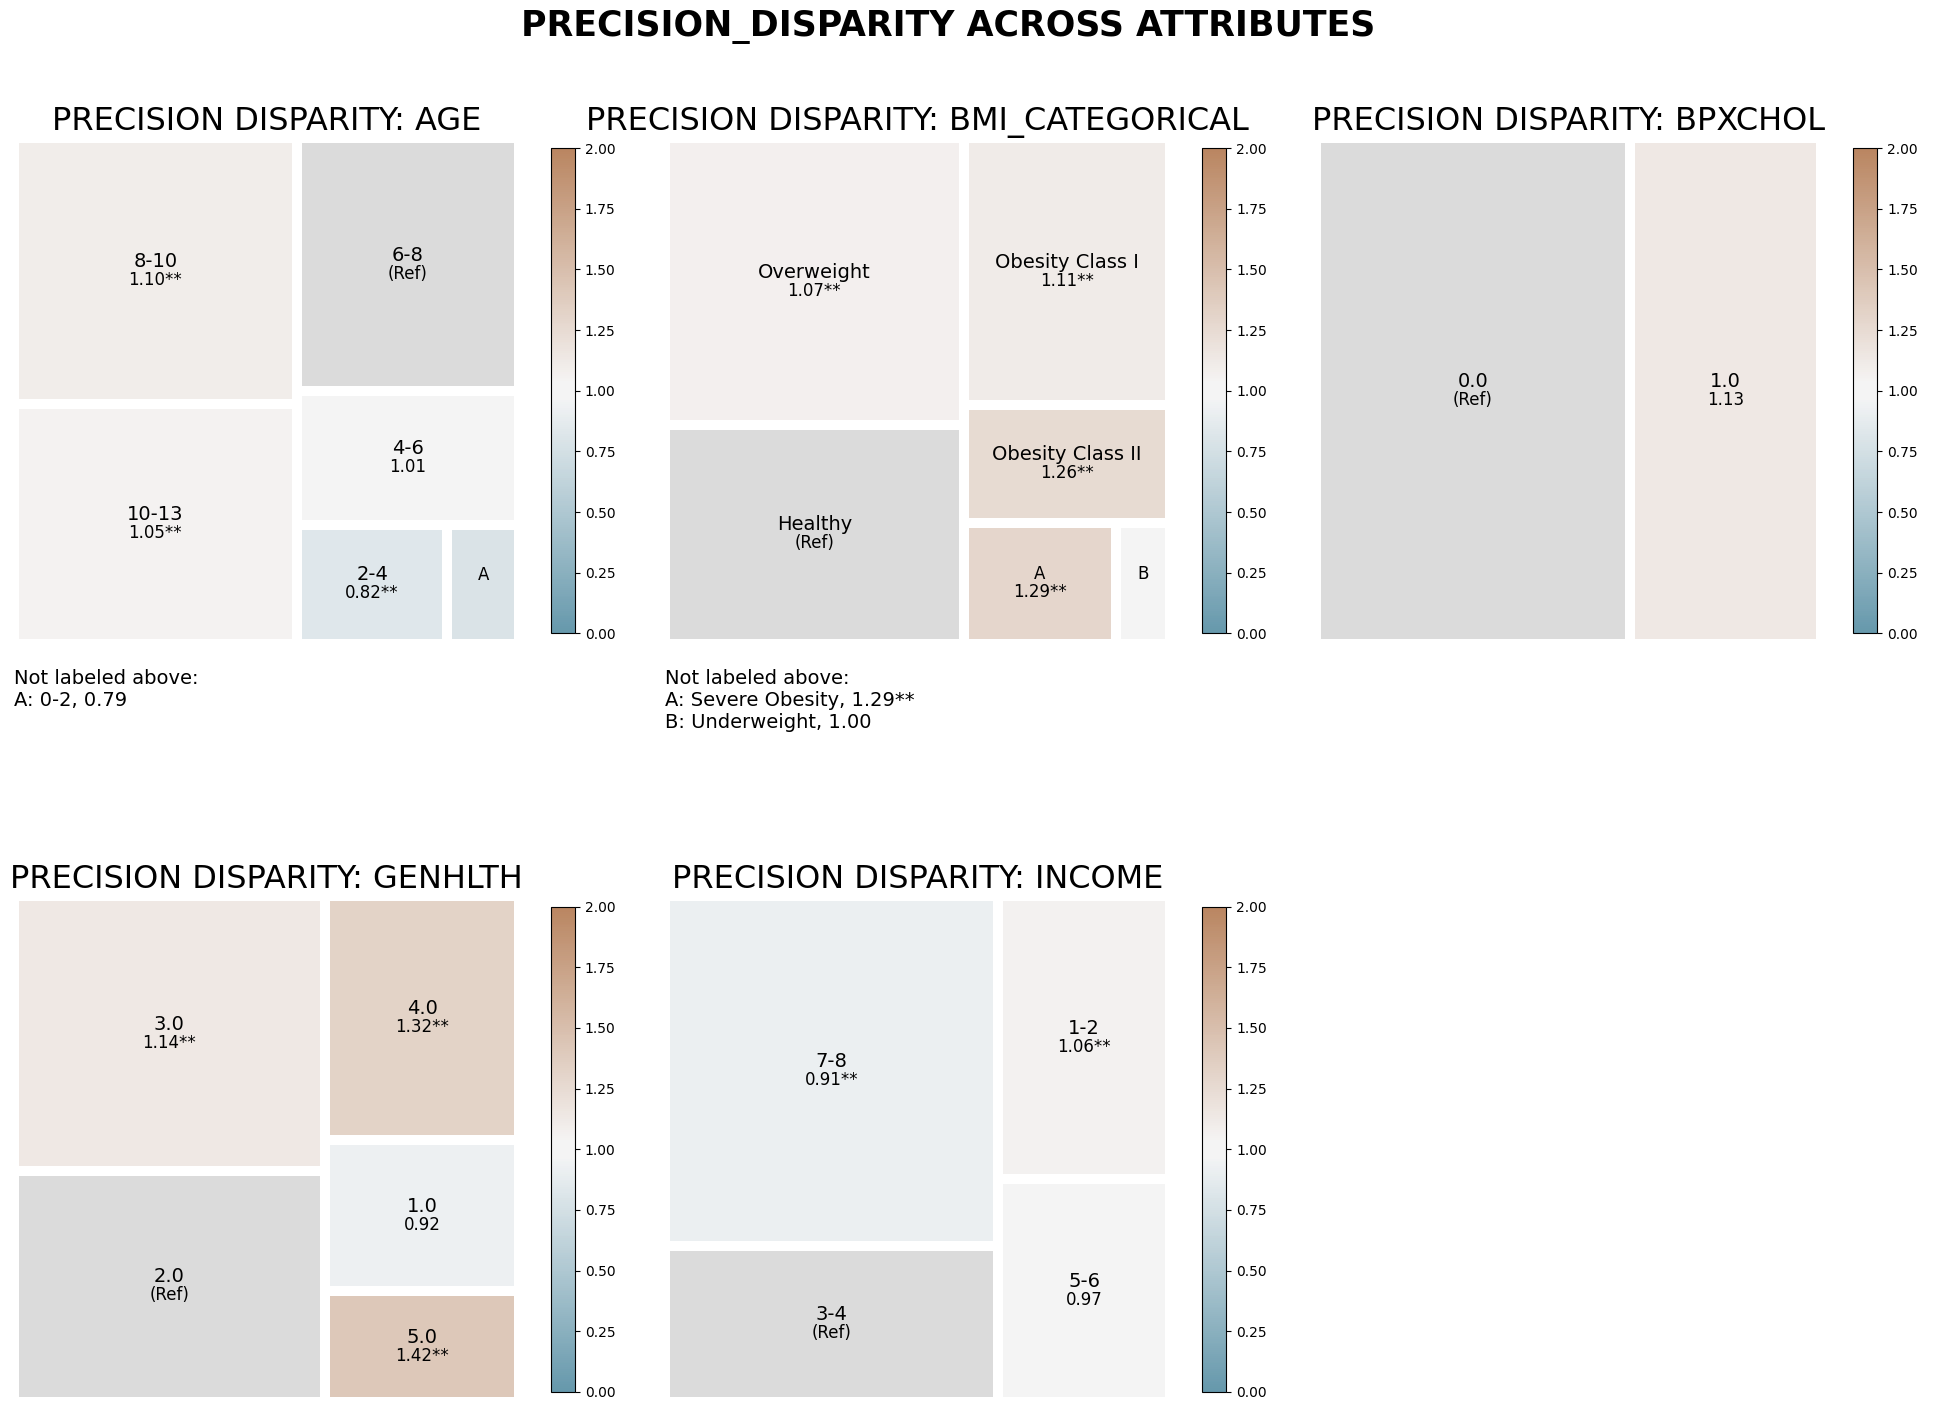

In [9]:
plot = Plot()
j = plot.plot_disparity_all(bias_df, metrics=['precision_disparity'], significance_alpha=0.05)

### Interpretation of Precision Disparities

The precision disparity visualization shows that the model generally has a similar ability to correctly predict positive diabetes cases across most **income and age groups**.

However:

- Precision is **lower for very young patients**, who represent a small portion of the dataset.
- Patients with **high blood pressure and cholesterol** also show lower precision.

A clear pattern appears for **BMI and general health categories**:

- The **higher the BMI**,
- The **worse the general health**

the **higher the precision** of the model.

This indicates that the model is better at predicting true positives (with fewer false positives) for individuals who already have significant health issues.

## True Positive Rate (Sensitivity) Disparities

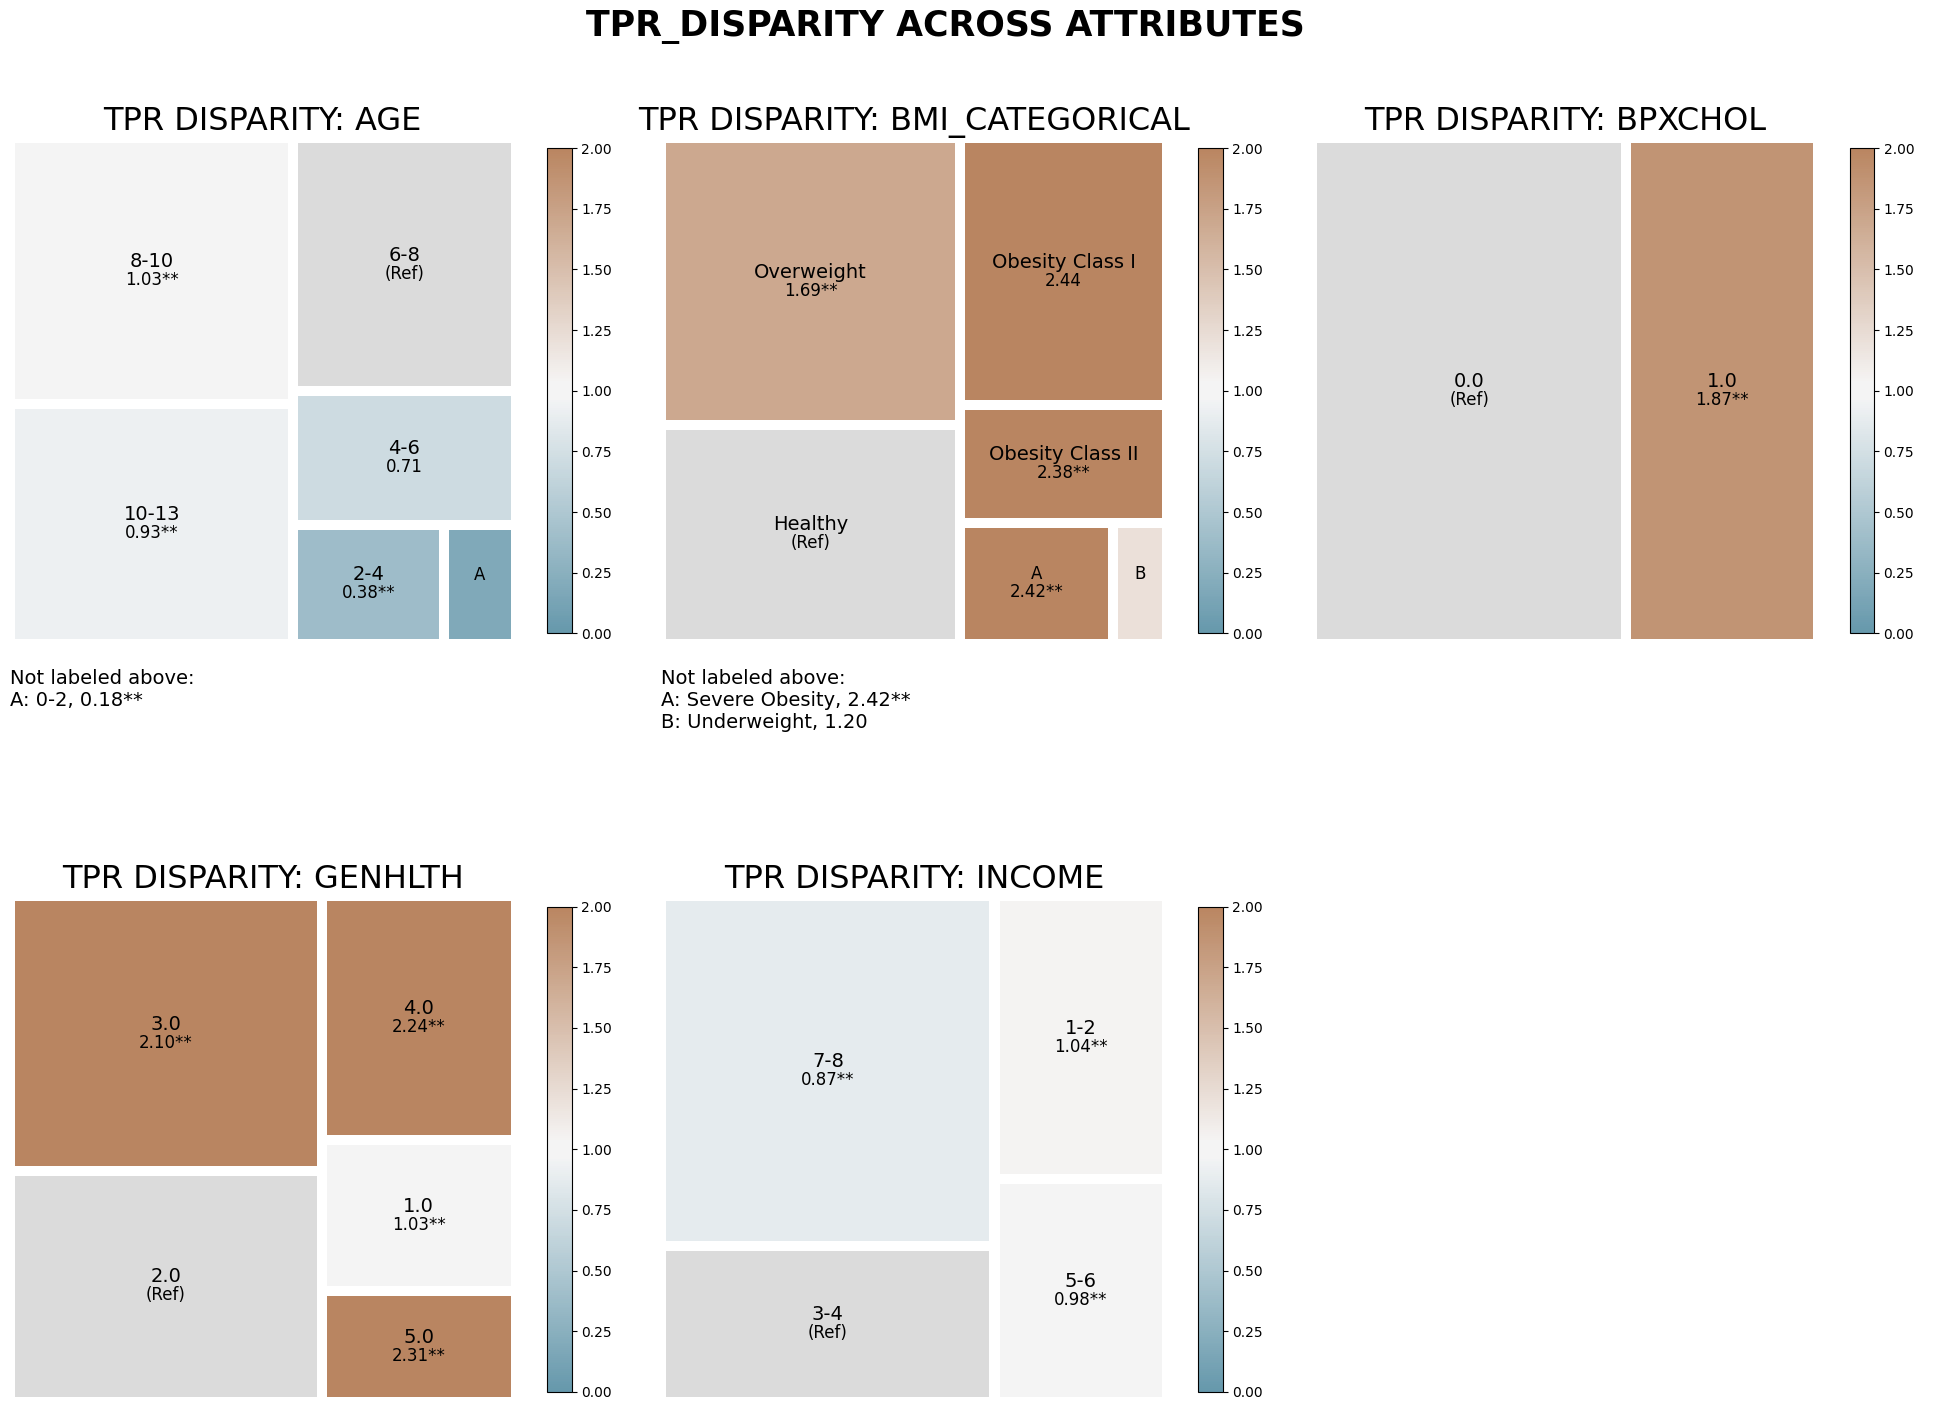

In [10]:
j = plot.plot_disparity_all(bias_df, metrics=['tpr_disparity'], significance_alpha=0.05)

### Interpretation of Sensitivity Disparities

Comparing the precision and sensitivity visualizations shows that **True Positive Rate (TPR) disparities are significantly larger**.

Except for income, every feature presents notable disparities.

Key observations include:

- **Age groups above 6** show higher sensitivity compared to younger groups.
- Patients with **higher BMI**, **higher blood pressure/cholesterol**, or **worse general health** have much higher recall.

For example:

- The sensitivity for **obese patients** is more than **twice as high** as for healthy individuals.

This means the model is better at **identifying diabetic patients with existing health issues** while missing more diabetic cases among healthier individuals.

## Key Findings

Combining the precision and sensitivity analyses highlights several important fairness concerns.
The model appears to discriminate against individuals who are generally healthy, particularly **younger patients**.

For these groups:

- Precision is lower, meaning they are **more likely to be incorrectly predicted as diabetic**.
- Sensitivity is also significantly lower, meaning **actual diabetic cases are more likely to be missed**.

The most significant imbalance appears in **True Positive Rate disparities**, where healthier groups experience substantially lower recall.

One possible explanation for this limitation is the **absence of genetic or hereditary features** in the dataset, which could play a significant role in predicting diabetes for individuals without obvious health risk factors.